1. Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

2. Load Data dan Persiapan Data

In [3]:
df = pd.read_excel(r'C:\Users\Nyimas Arsilla R\OneDrive\Pictures\Documents\project\DATA RUMAH.xlsx')

df.head(10)

,NO,NAMA RUMAH,HARGA,LB,LT,KT,KM,GRS
0,1,"Rumah Murah Hook Tebet Timur, Tebet, Jakarta S...",3800000000,220,220,3,3,0
1,2,"Rumah Modern di Tebet dekat Stasiun, Tebet, Ja...",4600000000,180,137,4,3,2
2,3,"Rumah Mewah 2 Lantai Hanya 3 Menit Ke Tebet, T...",3000000000,267,250,4,4,4
3,4,"Rumah Baru Tebet, Tebet, Jakarta Selatan",430000000,40,25,2,2,0
4,5,"Rumah Bagus Tebet komp Gudang Peluru lt 350m, ...",9000000000,400,355,6,5,3
5,6,Rumah Mewah Modern Murah 3 lantai di Tebet Jak...,4970000000,300,154,5,3,3
6,7,"Rumah lama di Tebet, dekat MT Haryono dan tol ...",2600000000,120,150,3,2,1
7,8,RUMAH BAGUS KEREN JALAN LEBAR DI AREA & KAWASA...,10500000000,350,247,4,4,0
8,9,Minimalis Baru Jalan 1 Mobil Akses Mudah Dekat...,3250000000,125,90,3,3,0
9,10,"Minimalis Baru Jalan 2 Mobil Tebet Timur, Tebe...",4500000000,250,96,5,4,1


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   NO          1010 non-null   int64 
 1   NAMA RUMAH  1010 non-null   object
 2   HARGA       1010 non-null   int64 
 3   LB          1010 non-null   int64 
 4   LT          1010 non-null   int64 
 5   KT          1010 non-null   int64 
 6   KM          1010 non-null   int64 
 7   GRS         1010 non-null   int64 
dtypes: int64(7), object(1)
memory usage: 63.3+ KB


In [25]:
df.describe()

,NO,HARGA,LB,LT,KT,KM,GRS
count,1010.000000,1.010000e+03,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000
mean,505.500000,7.628987e+09,276.539604,237.432673,4.668317,3.607921,1.920792
std,291.706188,7.340946e+09,177.864557,179.957604,1.572776,1.420066,1.510998
min,1.000000,4.300000e+08,40.000000,25.000000,2.000000,1.000000,0.000000
25%,253.250000,3.262500e+09,150.000000,130.000000,4.000000,3.000000,1.000000
50%,505.500000,5.000000e+09,216.500000,165.000000,4.000000,3.000000,2.000000
75%,757.750000,9.000000e+09,350.000000,290.000000,5.000000,4.000000,2.000000
max,1010.000000,6.500000e+10,1126.000000,1400.000000,10.000000,10.000000,10.000000


In [17]:
df.isnull().sum()

NO            0
NAMA RUMAH    0
HARGA         0
LB            0
LT            0
KT            0
KM            0
GRS           0
dtype: int64

In [5]:
df_clean = df.drop(columns=['NO', 'NAMA RUMAH'])
print(f'\nKolom fitur: {df_clean.columns.tolist()}')


Kolom fitur: ['HARGA', 'LB', 'LT', 'KT', 'KM', 'GRS']


3. Exploratory Data Analysis (EDA)

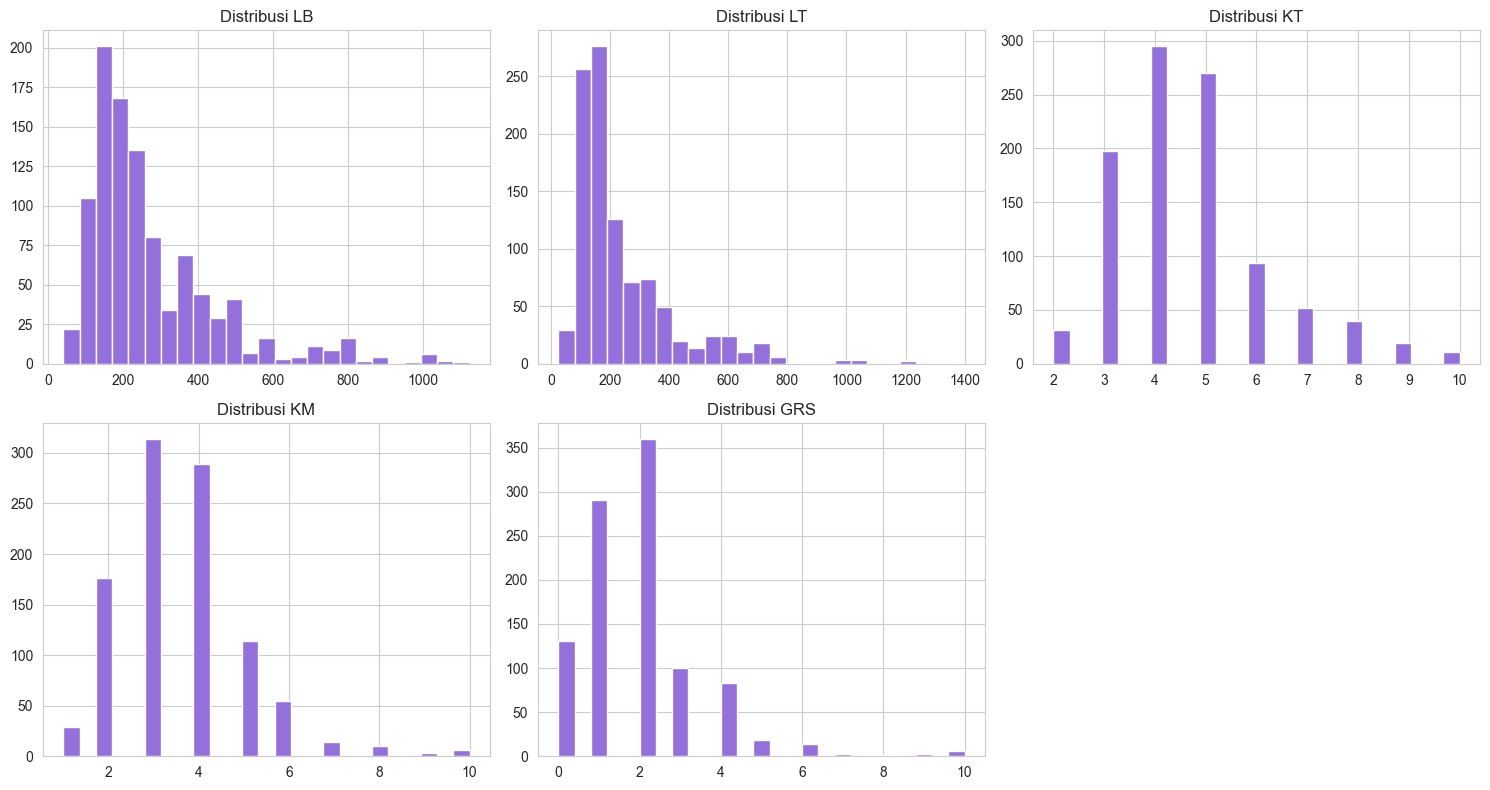

In [6]:
# Distribusi semua fitur
features = ['LB', 'LT', 'KT', 'KM', 'GRS']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df_clean[col], bins=25, color='mediumpurple', edgecolor='white')
    axes[i].set_title(f'Distribusi {col}')
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

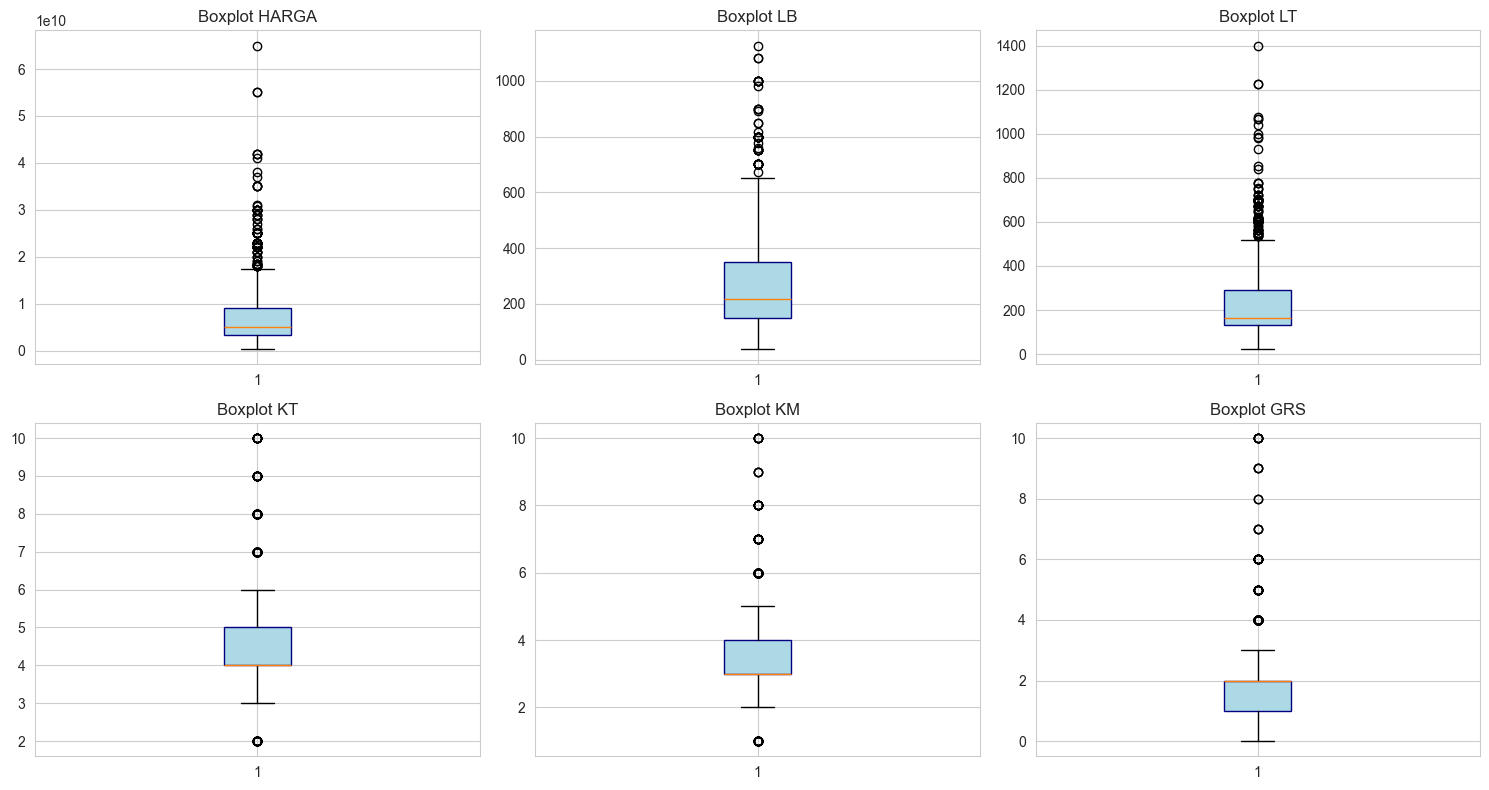

In [7]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(['HARGA', 'LB', 'LT', 'KT', 'KM', 'GRS']):
    axes[i].boxplot(df_clean[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'))
    axes[i].set_title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

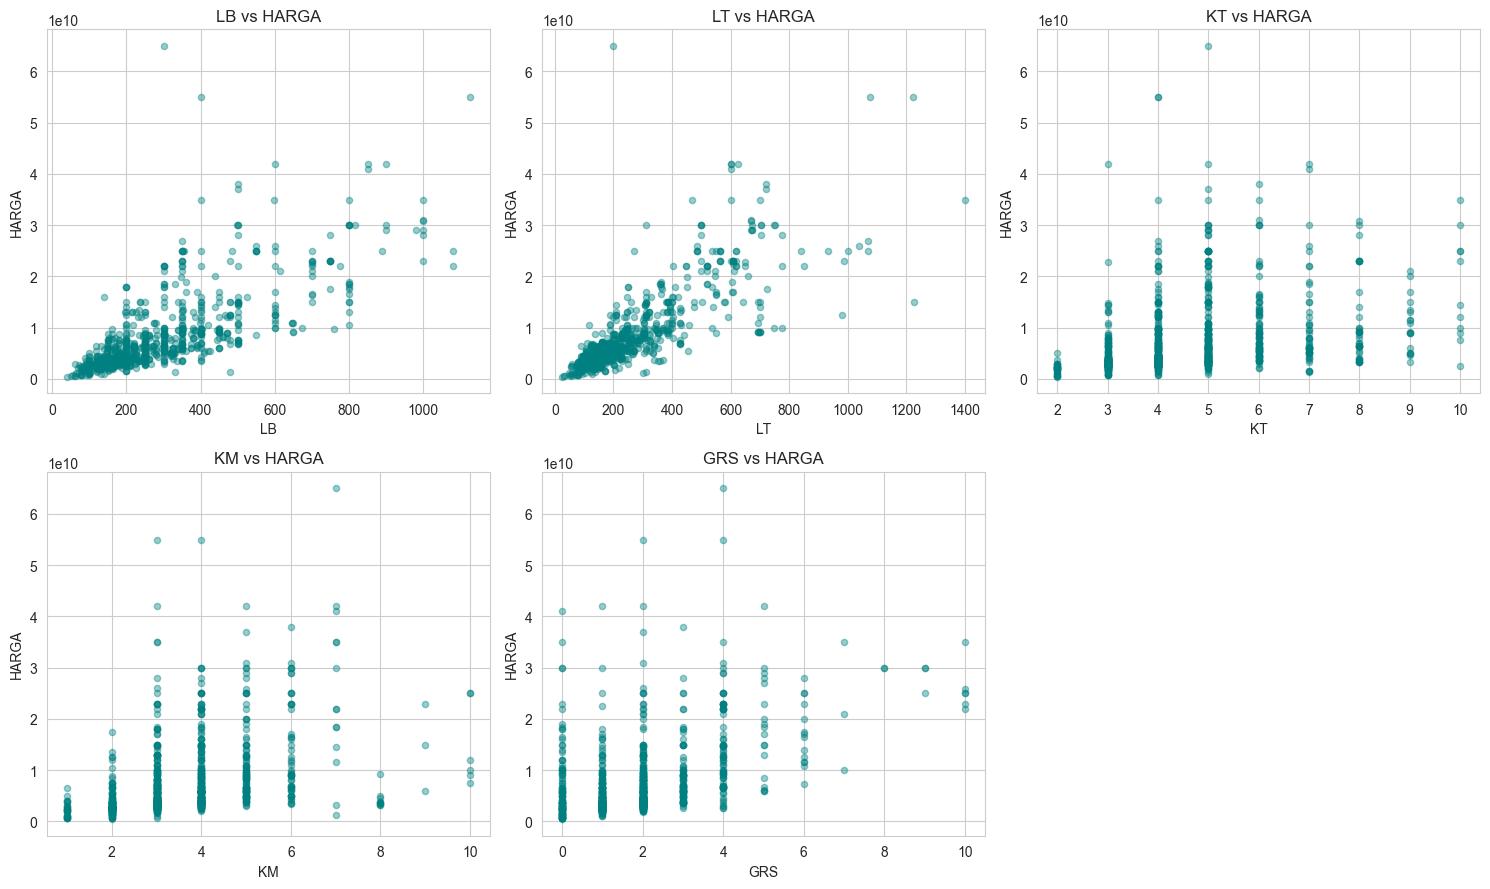

In [8]:
# Scatter plot setiap fitur vs HARGA
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].scatter(df_clean[col], df_clean['HARGA'], alpha=0.4, color='teal', s=20)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('HARGA')
    axes[i].set_title(f'{col} vs HARGA')
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

4. Feature Selection & Analisis Korelasi

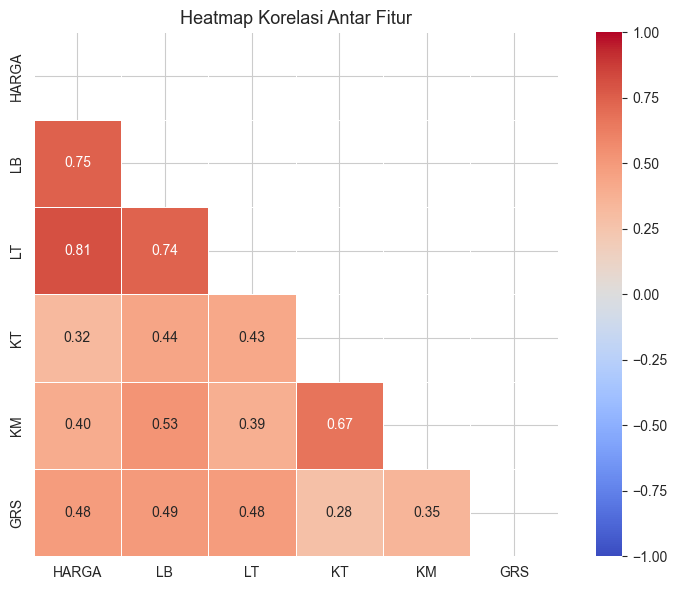

In [9]:
# Heatmap korelasi
corr_matrix = df_clean.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=13)
plt.tight_layout()
plt.show()

=== KORELASI FITUR vs HARGA ===
LT     0.809617
LB     0.747083
GRS    0.484892
KM     0.404770
KT     0.323320
Name: HARGA, dtype: float64


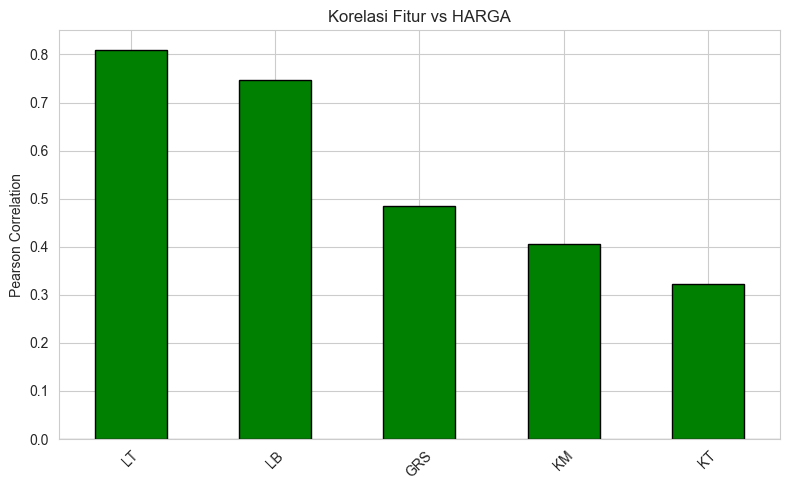

In [10]:
# Korelasi setiap fitur terhadap HARGA
corr_target = df_clean.corr()['HARGA'].drop('HARGA').sort_values(ascending=False)
print('=== KORELASI FITUR vs HARGA ===')
print(corr_target)

colors = ['green' if v > 0 else 'red' for v in corr_target.values]
corr_target.plot(kind='bar', color=colors, edgecolor='black', figsize=(8, 5))
plt.title('Korelasi Fitur vs HARGA')
plt.ylabel('Pearson Correlation')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# SelectKBest - F-regression score
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(df_clean[features], df_clean['HARGA'])

f_scores = pd.DataFrame({
    'Fitur': features,
    'F-Score': selector.scores_,
    'P-Value': selector.pvalues_
}).sort_values('F-Score', ascending=False)

print('=== F-REGRESSION SCORE ===')
print(f_scores.to_string(index=False))

selected_features = f_scores[f_scores['P-Value'] < 0.05]['Fitur'].tolist()
print(f'\nFitur terpilih (p < 0.05): {selected_features}')

=== F-REGRESSION SCORE ===
Fitur     F-Score       P-Value
   LT 1917.813736 1.767587e-235
   LB 1273.228313 5.668265e-181
  GRS  309.854116  1.106725e-60
   KM  197.509166  4.215935e-41
   KT  117.673365  5.237501e-26

Fitur terpilih (p < 0.05): ['LT', 'LB', 'GRS', 'KM', 'KT']


5. Pre-Processing

In [12]:
# Hapus outlier ekstrem pada HARGA dengan IQR
Q1 = df_clean['HARGA'].quantile(0.25)
Q3 = df_clean['HARGA'].quantile(0.75)
IQR = Q3 - Q1
df_model = df_clean[
    (df_clean['HARGA'] >= Q1 - 3*IQR) &
    (df_clean['HARGA'] <= Q3 + 3*IQR)
].copy()
print(f'Data sebelum: {len(df_clean)} | Sesudah: {len(df_model)} | Dihapus: {len(df_clean)-len(df_model)}')

Data sebelum: 1010 | Sesudah: 979 | Dihapus: 31


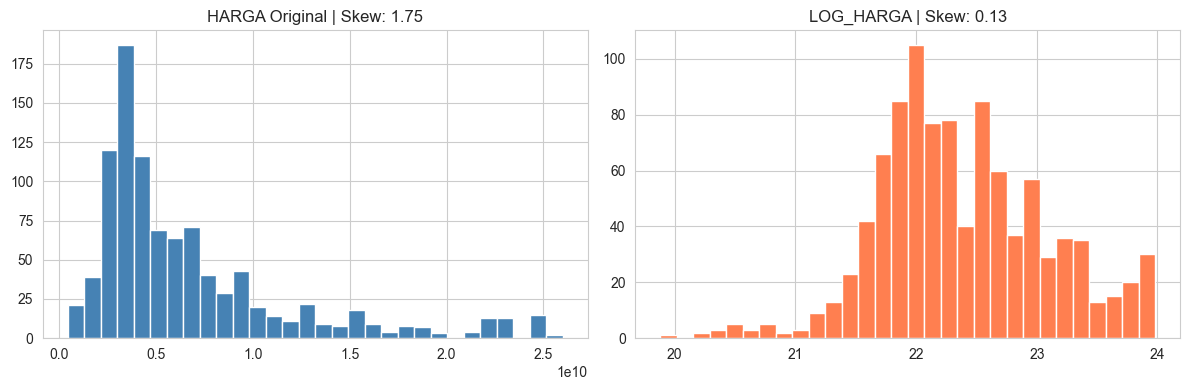

In [13]:
# Log transform HARGA
df_model['LOG_HARGA'] = np.log1p(df_model['HARGA'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_model['HARGA'], bins=30, color='steelblue')
axes[0].set_title(f'HARGA Original | Skew: {df_model["HARGA"].skew():.2f}')
axes[1].hist(df_model['LOG_HARGA'], bins=30, color='coral')
axes[1].set_title(f'LOG_HARGA | Skew: {df_model["LOG_HARGA"].skew():.2f}')
plt.tight_layout()
plt.show()

In [14]:
# Split fitur & target, lalu scaling
X = df_model[selected_features]
y = df_model['LOG_HARGA']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')

Train: (783, 5) | Test: (196, 5)


6. Modelling & Evaluasi

In [15]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_pred_orig = np.expm1(y_pred)
    y_true_orig = np.expm1(y_te)

    mae  = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    r2   = r2_score(y_te, y_pred)
    cv   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')

    print(f'\n{'='*45}')
    print(f'  MODEL: {name}')
    print(f'{'='*45}')
    print(f'  MAE  : Rp {mae:>15,.0f}')
    print(f'  RMSE : Rp {rmse:>15,.0f}')
    print(f'  R²   : {r2:.4f}')
    print(f'  CV R² (5-fold): {cv.mean():.4f} ± {cv.std():.4f}')
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV_R2': cv.mean()}

results = []

In [16]:
lr = LinearRegression()
results.append(evaluate_model('Linear Regression', lr, X_train_s, y_train, X_test_s, y_test))


  MODEL: Linear Regression
  MAE  : Rp   2,004,732,165
  RMSE : Rp   3,518,827,042
  R²   : 0.7375
  CV R² (5-fold): 0.6583 ± 0.0666


In [17]:
ridge = Ridge(alpha=10)
results.append(evaluate_model('Ridge Regression', ridge, X_train_s, y_train, X_test_s, y_test))


  MODEL: Ridge Regression
  MAE  : Rp   2,005,843,456
  RMSE : Rp   3,508,657,810
  R²   : 0.7362
  CV R² (5-fold): 0.6585 ± 0.0658


In [18]:
lasso = Lasso(alpha=0.001)
results.append(evaluate_model('Lasso Regression', lasso, X_train_s, y_train, X_test_s, y_test))


  MODEL: Lasso Regression
  MAE  : Rp   2,004,016,271
  RMSE : Rp   3,510,893,783
  R²   : 0.7369
  CV R² (5-fold): 0.6584 ± 0.0664


In [19]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
results.append(evaluate_model('Random Forest', rf, X_train_s, y_train, X_test_s, y_test))


  MODEL: Random Forest
  MAE  : Rp   1,255,548,743
  RMSE : Rp   2,041,791,458
  R²   : 0.8480
  CV R² (5-fold): 0.8106 ± 0.0429


In [20]:
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
results.append(evaluate_model('Gradient Boosting', gb, X_train_s, y_train, X_test_s, y_test))


  MODEL: Gradient Boosting
  MAE  : Rp   1,319,018,966
  RMSE : Rp   2,163,528,494
  R²   : 0.8501
  CV R² (5-fold): 0.8083 ± 0.0376



=== PERBANDINGAN SEMUA MODEL ===
            Model       R2    CV_R2          MAE         RMSE
Gradient Boosting 0.850067 0.808270 1.319019e+09 2.163528e+09
    Random Forest 0.848048 0.810559 1.255549e+09 2.041791e+09
Linear Regression 0.737479 0.658347 2.004732e+09 3.518827e+09
 Lasso Regression 0.736937 0.658438 2.004016e+09 3.510894e+09
 Ridge Regression 0.736150 0.658481 2.005843e+09 3.508658e+09


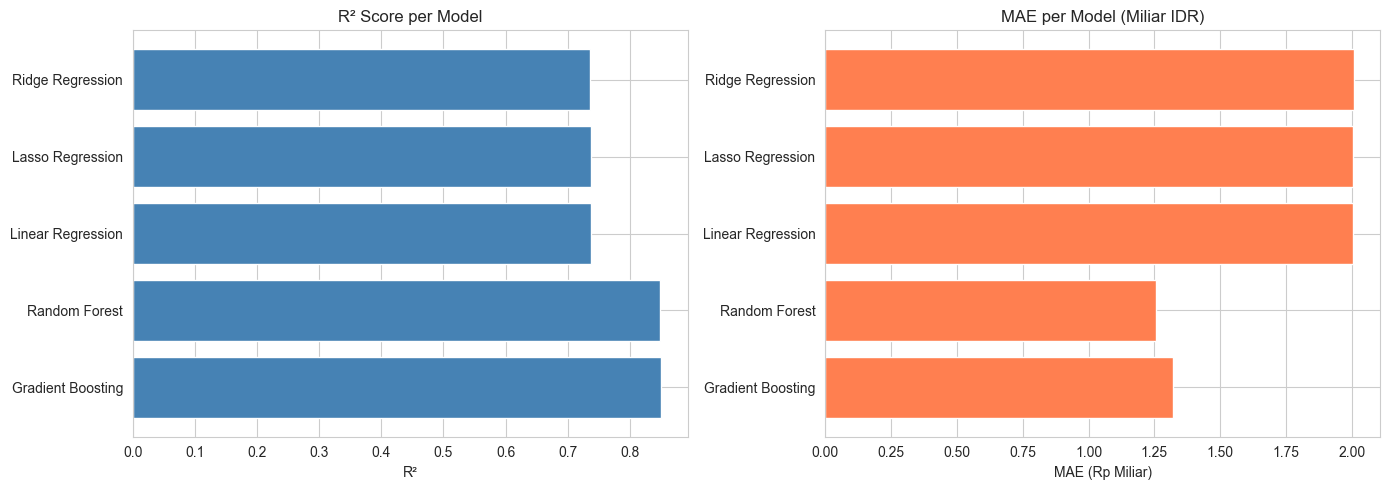

In [21]:
# Perbandingan semua model
df_results = pd.DataFrame(results).sort_values('R2', ascending=False)
print('\n=== PERBANDINGAN SEMUA MODEL ===')
print(df_results[['Model','R2','CV_R2','MAE','RMSE']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(df_results['Model'], df_results['R2'], color='steelblue', edgecolor='white')
axes[0].set_title('R² Score per Model')
axes[0].set_xlabel('R²')

axes[1].barh(df_results['Model'], df_results['MAE']/1e9, color='coral', edgecolor='white')
axes[1].set_title('MAE per Model (Miliar IDR)')
axes[1].set_xlabel('MAE (Rp Miliar)')
plt.tight_layout()
plt.show()

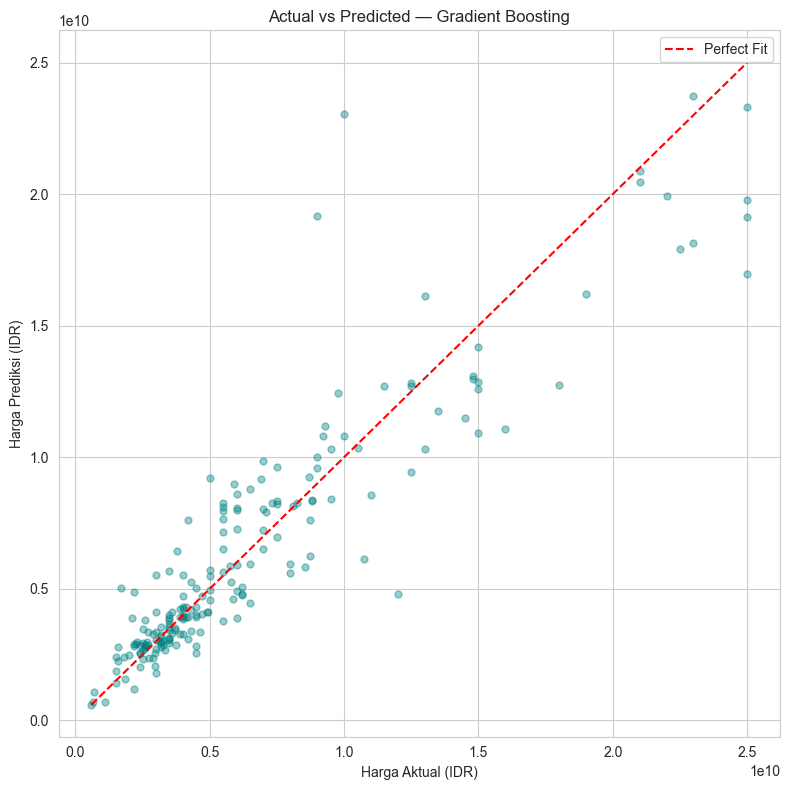

In [22]:
# Actual vs Predicted — Best Model
best_name = df_results.iloc[0]['Model']
model_map = {'Linear Regression': lr, 'Ridge Regression': ridge,
             'Lasso Regression': lasso, 'Random Forest': rf, 'Gradient Boosting': gb}
best_model = model_map[best_name]

y_pred_best = best_model.predict(X_test_s)
y_actual    = np.expm1(y_test)
y_predicted = np.expm1(y_pred_best)

plt.figure(figsize=(8, 8))
plt.scatter(y_actual, y_predicted, alpha=0.4, color='teal', s=25)
lim = [min(y_actual.min(), y_predicted.min()), max(y_actual.max(), y_predicted.max())]
plt.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect Fit')
plt.xlabel('Harga Aktual (IDR)')
plt.ylabel('Harga Prediksi (IDR)')
plt.title(f'Actual vs Predicted — {best_name}')
plt.legend()
plt.tight_layout()
plt.show()

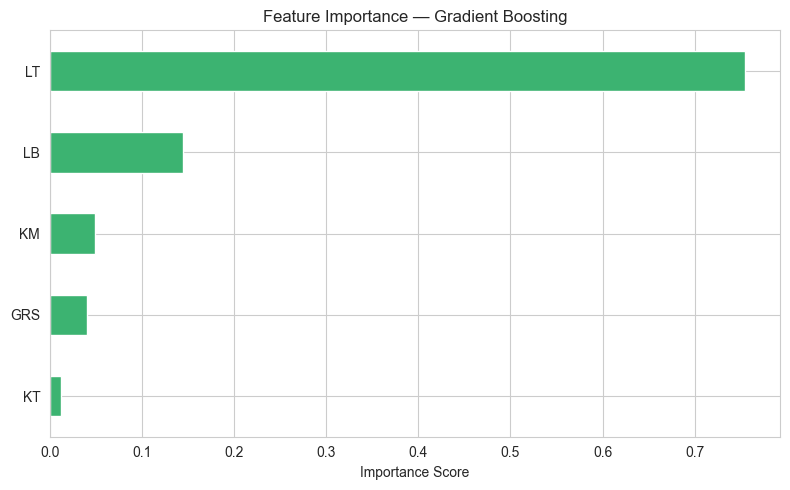

In [23]:
# Feature Importance / Koefisien
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=selected_features).sort_values()
    importances.plot(kind='barh', color='mediumseagreen', edgecolor='white', figsize=(8, 5))
    plt.title(f'Feature Importance — {best_name}')
    plt.xlabel('Importance Score')
else:
    coef = pd.Series(best_model.coef_, index=selected_features).sort_values()
    coef.plot(kind='barh', color='mediumpurple', edgecolor='white', figsize=(8, 5))
    plt.title(f'Koefisien Fitur — {best_name}')
    plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

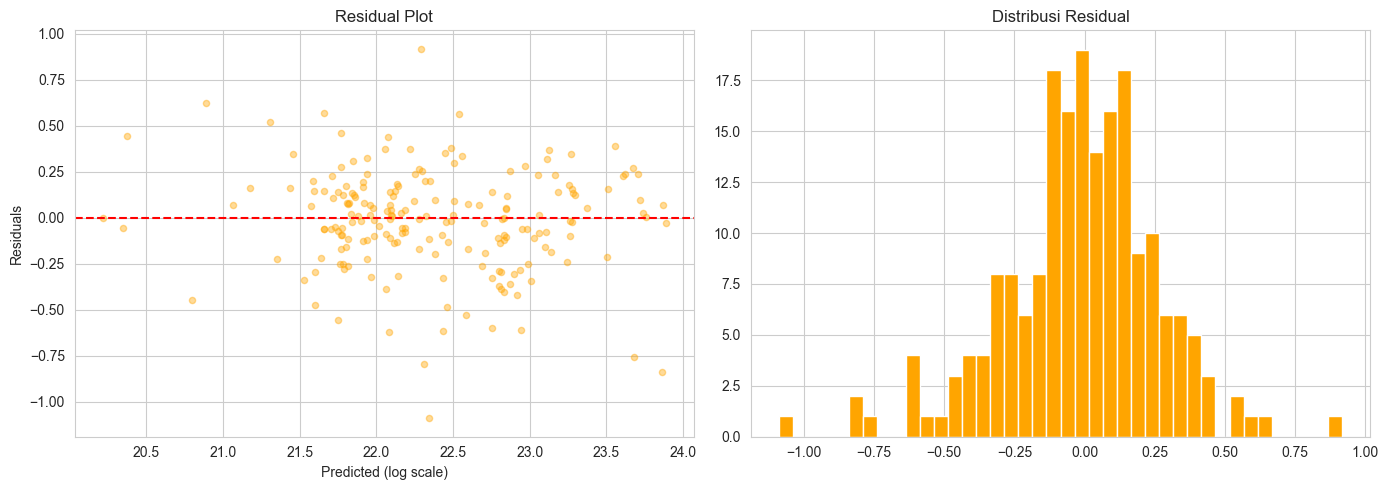


Model Terbaik: Gradient Boosting
R²   : 0.8501
MAE  : Rp 1,319,018,966
RMSE : Rp 2,163,528,494


In [24]:
# Residual Plot
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_best, residuals, alpha=0.4, color='orange', s=20)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted (log scale)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot')

axes[1].hist(residuals, bins=40, color='orange', edgecolor='white')
axes[1].set_title('Distribusi Residual')
plt.tight_layout()
plt.show()

print(f'\nModel Terbaik: {best_name}')
best_row = df_results.iloc[0]
print(f'R²   : {best_row["R2"]:.4f}')
print(f'MAE  : Rp {best_row["MAE"]:,.0f}')
print(f'RMSE : Rp {best_row["RMSE"]:,.0f}')